# Introducing Colab

Learn about Google Colab and set up a Google account (if you don't already have one) [here](https://colab.research.google.com/)

You should be able to use the free tier or minimal spend to complete all the projects in the class. I personally signed up for Colab Pro+ and I'm loving it - but it's not required.

To see some of what Colab can do, please follow the link below!

https://colab.research.google.com/drive/1DjcrYDZldAXKJ08x1uYIVCtItoLPk1Wr?usp=sharing

In [1]:
# Instead running the file in colab, I want to run it locally (I have a high-end GPU that is faster than the T4)
# Therefore I added in the code from the colab file, and installed the required packages (uv add transfromers, diffusers)



In [10]:
# Testing whether Cuda works:

import torch
print(f"Is cuda available? {torch.cuda.is_available()} \n Device is {torch.cuda.get_device_name(0)}")

Is cuda available? True 
 Device is NVIDIA GeForce RTX 4090 Laptop GPU


In [20]:
from dotenv import load_dotenv
import os
from huggingface_hub import login


In [26]:
load_dotenv()

True

In [30]:
hf_token = os.environ.get('HUGGING_FACE')

Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


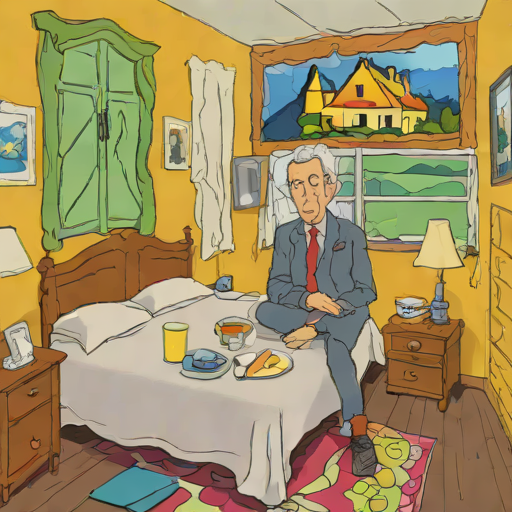

In [34]:
from IPython.display import display
from diffusers import AutoPipelineForText2Image
import torch

pipe = AutoPipelineForText2Image.from_pretrained("stabilityai/sdxl-turbo", torch_dtype=torch.float16, variant="fp16", token = hf_token)
pipe.to("cuda")
prompt = "A stressed out bed and breakfast owner in France in a pop style art"
image = pipe(prompt=prompt, num_inference_steps=4, guidance_scale=0.0).images[0]
display(image)